In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

**Introduction** \|\| [Tensors](tensors_deeper_tutorial.html) \|\|
[Autograd](autogradyt_tutorial.html) \|\| [Building
Models](modelsyt_tutorial.html) \|\| [TensorBoard
Support](tensorboardyt_tutorial.html) \|\| [Training
Models](trainingyt.html) \|\| [Model Understanding](captumyt.html)

Introduction to PyTorch
=======================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=IC0_FRiX-sw).



In [4]:
# Run this cell to load the video
from IPython.display import display, HTML
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/IC0_FRiX-sw" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
display(HTML(html_code))



PyTorch Tensors
---------------

Follow along with the video beginning at
[03:50](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=230s).

First, we'll import pytorch.


In [5]:
import torch

Let's see a few basic tensor manipulations. First, just a few of the
ways to create tensors:


In [6]:
z = torch.zeros(5, 3)  # Crea un tensor de tamaño 5x3 lleno de ceros
print(z)  # Muestra el contenido del tensor en pantalla
print(z.dtype)  # Muestra el tipo de dato de los elementos del tensor

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.float32


Above, we create a 5x3 matrix filled with zeros, and query its datatype
to find out that the zeros are 32-bit floating point numbers, which is
the default PyTorch.

What if you wanted integers instead? You can always override the
default:


In [7]:
i = torch.ones((5, 3), dtype=torch.int16)
print(i)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)


You can see that when we do change the default, the tensor helpfully
reports this when printed.

It's common to initialize learning weights randomly, often with a
specific seed for the PRNG for reproducibility of results:


In [8]:
torch.manual_seed(1729)  # Fija la semilla para que los valores aleatorios sean reproducibles
r1 = torch.rand(2, 2)  # Genera el primer tensor aleatorio de tamaño 2x2
print('A random tensor:')  # Imprime un título descriptivo para la primera salida
print(r1)  # Muestra el contenido del primer tensor aleatorio

r2 = torch.rand(2, 2)  # Genera un segundo tensor aleatorio (distinto porque no se resembró aún)
print('\nA different random tensor:')  # Imprime un título en nueva línea para separar la salida
print(r2) # Muestra el segundo tensor con nuevos valores aleatorios

torch.manual_seed(1729)  # Restablece la misma semilla para repetir la secuencia aleatoria
r3 = torch.rand(2, 2)  # Genera un tensor que debe coincidir con r1
print('\nShould match r1:')  # Imprime un aviso indicando que debería coincidir con r1
print(r3) # Muestra el tercer tensor; repite los valores de r1 al usar la misma semilla

A random tensor:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])

A different random tensor:
tensor([[0.4216, 0.0691],
        [0.2332, 0.4047]])

Should match r1:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])


PyTorch tensors perform arithmetic operations intuitively. Tensors of
similar shapes may be added, multiplied, etc. Operations with scalars
are distributed over the tensor:


In [9]:
ones = torch.ones(2, 3)  # Crea un tensor 2x3 lleno de unos
print(ones)  # Muestra el tensor de unos
print(ones.shape)  # Imprime la forma del tensor de unos

twos = torch.ones(2, 3) * 2  # Crea un tensor 2x3 y multiplica cada elemento por 2
print(twos)  # Muestra el tensor de doses

threes = ones + twos  # Suma elemento a elemento los tensores ones y twos (misma forma)
print(threes)  # Imprime el resultado de la suma elemento a elemento
print(threes.shape)  # Imprime la forma del tensor resultante

r1 = torch.rand(2, 3)  # Genera un tensor aleatorio de forma 2x3
r2 = torch.rand(3, 2)  # Genera otro tensor aleatorio de forma 3x2 (forma incompatible para suma directa)
# uncomment this line to get a runtime error
# r3 = r1 + r2

tensor([[1., 1., 1.],
        [1., 1., 1.]])
torch.Size([2, 3])
tensor([[2., 2., 2.],
        [2., 2., 2.]])
tensor([[3., 3., 3.],
        [3., 3., 3.]])
torch.Size([2, 3])


Here's a small sample of the mathematical operations available:


In [10]:
r = (torch.rand(2, 2) - 0.5) * 2  # Genera una matriz aleatoria 2x2 con valores en el rango [-1, 1]
print('A random matrix, r:')  # Imprime un título para identificar la matriz base
print(r)  # Muestra la matriz aleatoria original

# Operaciones matemáticas comunes sobre el tensor r:
print('\nAbsolute value of r:')  # Imprime un encabezado para el valor absoluto
print(torch.abs(r))  # Calcula y muestra el valor absoluto elemento a elemento

# Funciones trigonométricas aplicadas al tensor:
print('\nInverse sine of r:')  # Imprime un encabezado para el arco seno
print(torch.asin(r))  # Calcula y muestra el arco seno (asin) de cada elemento

# Operaciones de álgebra lineal sobre la matriz:
print('\nDeterminant of r:')  # Imprime un encabezado para el determinante
print(torch.det(r))  # Calcula y muestra el determinante de la matriz 2x2
print('\nSingular value decomposition of r:')  # Imprime un encabezado para la descomposición SVD
print(torch.svd(r))  # Calcula y muestra la descomposición en valores singulares

# Operaciones estadísticas y de agregación:
print('\nAverage and standard deviation of r:')  # Imprime un encabezado para media y desviación estándar
print(torch.std_mean(r))  # Devuelve y muestra desviación estándar y media del tensor
print('\nMaximum value of r:')  # Imprime un encabezado para el valor máximo
print(torch.max(r))  # Obtiene y muestra el valor máximo de r

A random matrix, r:
tensor([[ 0.9956, -0.2232],
        [ 0.3858, -0.6593]])

Absolute value of r:
tensor([[0.9956, 0.2232],
        [0.3858, 0.6593]])

Inverse sine of r:
tensor([[ 1.4775, -0.2251],
        [ 0.3961, -0.7199]])

Determinant of r:
tensor(-0.5703)

Singular value decomposition of r:
torch.return_types.svd(
U=tensor([[-0.8353, -0.5497],
        [-0.5497,  0.8353]]),
S=tensor([1.1793, 0.4836]),
V=tensor([[-0.8851, -0.4654],
        [ 0.4654, -0.8851]]))

Average and standard deviation of r:
(tensor(0.7217), tensor(0.1247))

Maximum value of r:
tensor(0.9956)


There's a good deal more to know about the power of PyTorch tensors,
including how to set them up for parallel computations on GPU - we'll be
going into more depth in another video.

PyTorch Models
==============

Follow along with the video beginning at
[10:00](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=600s).

Let's talk about how we can express models in PyTorch


In [1]:
import torch                     # for all things PyTorch
import torch.nn as nn            # for torch.nn.Module, the parent object for PyTorch models
import torch.nn.functional as F  # for the activation function

![](https://pytorch.org/tutorials/_static/img/mnist.png)

*Figure: LeNet-5*

Above is a diagram of LeNet-5, one of the earliest convolutional neural
nets, and one of the drivers of the explosion in Deep Learning. It was
built to read small images of handwritten numbers (the MNIST dataset),
and correctly classify which digit was represented in the image.

Here's the abridged version of how it works:

-   Layer C1 is a convolutional layer, meaning that it scans the input
    image for features it learned during training. It outputs a map of
    where it saw each of its learned features in the image. This
    "activation map" is downsampled in layer S2.
-   Layer C3 is another convolutional layer, this time scanning C1's
    activation map for *combinations* of features. It also puts out an
    activation map describing the spatial locations of these feature
    combinations, which is downsampled in layer S4.
-   Finally, the fully-connected layers at the end, F5, F6, and OUTPUT,
    are a *classifier* that takes the final activation map, and
    classifies it into one of ten bins representing the 10 digits.

How do we express this simple neural network in code?


In [2]:
class LeNet(nn.Module):
    # AQUI SE DEFINEN LAS CAPAS DE LA RED, LOS PARÁMETROS DE CADA CAPA Y SE ASOCIAN A NOMBRES (conv1, conv2, fc1, etc.). LO QUE REALMENTE SE EJECUTA ES EL FORWARD EN FUNCIÓN DE LO QUE HAY DEFINIDO EN ESTE MÉTODO "__init__".
    def __init__(self):
        super(LeNet, self).__init__()
        # Primera convolución.
        # 1 canal de entrada (imagen en escala de grises), 6 canales de salida y kernel de 5x5.
        # Es la capa C1 de la imagen de la red. Aprende 6 filtros (kernels)
        # Se aplica a la linea de código "x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))" en el método forward.
        self.conv1 = nn.Conv2d(1, 6, 5)
        
        # Segunda convolución: recibe 6 mapas de activación y produce 16 con kernel de 5x5.
        # Esta capa exige 6 canales de entrada, que son justamente los que dejó la línea anterior en x al terminar de ejecutar "x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))"
        # Es la capa C3 de la imagen de la red. Aprende 16 filtros (kernels)
        # Se aplica a la linea de código "x = F.max_pool2d(F.relu(self.conv2(x)), 2)" en el método forward.
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        # Capas totalmente conectadas para clasificación final en 10 clases
        # Lo aplanado en "x = x.view(-1, self.num_flat_features(x))" entra en fc1 y sale con 120 características.
        # Es la capa F5 de la imagen. 5 y 5 = alto y ancho espaciales que quedan tras reducciones
        # Se aplica a la linea de código "x = F.relu(self.fc1(x))" en el método forward.
        """
        ¿Porqué 5 * 5? 
        Porque en LeNet las dimensiones se van reduciendo así (sin padding, stride=1 en conv, y pool de 2x2):
            -Entrada: (32 x 32)
            .conv1 con kernel 5: (32 - 5 + 1 = 28) → (28 x 28)
            -max_pool2d(..., 2): (28 / 2 = 14) → (14 x 14)
            -conv2 con kernel 5: (14 - 5 + 1 = 10) → (10 x 10)
            -max_pool2d(..., 2): (10 / 2 = 5) → (5 x 5)
        Por eso, antes de aplanar, cada muestra queda con forma (16, 5, 5) y en fc1 aparece 16 * 5 * 5.
        Ver: 
            https://ezyang.github.io/convolution-visualizer/
            https://github.com/vdumoulin/conv_arithmetic?tab=readme-ov-file            
        """
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 16 canales de tamaño 5x5 tras conv+pool
        
        # Es la capa F6 de la imagen de la red.
        # La saluda de fc1 entra en fc2 una vez ejecutado "x = F.relu(self.fc1(x))".
        self.fc2 = nn.Linear(120, 84)
        
        # Es la capa OUTPUT de la imagen de la red.
        # La salida de fc2 entra en fc3 una vez ejecutado "x = F.relu(self.fc2(x))".
        # La salida de fc2 entra en la capa final y produce 10 logits al ejecutar "x = self.fc3(x)".
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Conv1 -> ReLU -> MaxPool(2x2): extrae características básicas y reduce resolución
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        
        # Conv2 -> ReLU -> MaxPool(2x2): combina características y vuelve a reducir tamaño
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        
        # Aplanar tensor para pasarlo a capas lineales (batch_size, features)
        # Convierte el tensor 4D de convoluciones en 2D para poder entrar a capas lineales.
        # Eso aplana cada muestra a un vector de tamaño: 16 * 5 * 5 = 400
        x = x.view(-1, self.num_flat_features(x))
        
        # Capas densas con ReLU para aprender representaciones no lineales
        # fc1 necesita que cada ejemplo entre con 400 características.
        # La salida de fc1 tiene 120 características, que se pasan a fc2 con ReLU.
        x = F.relu(self.fc1(x))
        
        # La salida de fc1 entra en fc2 una vez ejecutado "x = F.relu(self.fc1(x))".
        # La salida de fc2 tiene 84 características, que se pasan a la capa final con ReLU.
        x = F.relu(self.fc2(x))
        
        # Capa de salida: logits (sin softmax, útil para CrossEntropyLoss)
        # La salida de fc2 entra en la capa final y produce 10 logits al ejecutar "x = self.fc3(x)".
        x = self.fc3(x)
        return x

    # Estas líneas de num_flat_features calculan cuántas características hay que aplanar para que view(...) encaje con fc1.
    def num_flat_features(self, x):
        # toma todas las dimensiones excepto la del lote (batch)
        size = x.size()[1:]
        num_features = 1
        # multiplica dimensiones para obtener el total de características al aplanar
        for s in size:
            num_features *= s
        return num_features

Looking over this code, you should be able to spot some structural
similarities with the diagram above.

This demonstrates the structure of a typical PyTorch model:

-   It inherits from `torch.nn.Module` - modules may be nested - in
    fact, even the `Conv2d` and `Linear` layer classes inherit from
    `torch.nn.Module`.
-   A model will have an `__init__()` function, where it instantiates
    its layers, and loads any data artifacts it might need (e.g., an NLP
    model might load a vocabulary).
-   A model will have a `forward()` function. This is where the actual
    computation happens: An input is passed through the network layers
    and various functions to generate an output.
-   Other than that, you can build out your model class like any other
    Python class, adding whatever properties and methods you need to
    support your model's computation.

Let's instantiate this object and run a sample input through it.


In [5]:
# Creamos una instancia de la red LeNet y mostramos su arquitectura.
net = LeNet()
print(net)  # Muestra la arquitectura del modelo (capas, tamaños y parámetros).

input = torch.rand(1, 1, 32, 32)  # Crea una imagen ficticia: lote o batch=1 (una imagen), canal=1, alto=32, ancho=32.
print('\nImage batch shape:')
print(input.shape)  # Verifica que la forma del tensor de entrada sea la esperada por LeNet.

# Ejecuta una pasada hacia adelante (forward); ¡¡¡OJO: no se llama forward() directamente.!!!
# obtiene logits (puntuaciones crudas por clase).
output = net(input)  

# Salida de la red, inferencia realizada sobre la imagen aleatoria creada.
# No se ha aplicado softmax, por lo que la salida son logits (valores crudos) sin normalizar.
# ¡¡¡OJO: No ha aprendido todavía, por lo que la salida no debe ser una buena predicción.!!!
print('\nRaw output:')
print(output)  # Imprime los logits: puntuaciones sin normalizar para cada una de las 10 clases.
print(output.shape)  # Debe ser (1, 10): una predicción para cada clase del único elemento del lote.

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Image batch shape:
torch.Size([1, 1, 32, 32])

Raw output:
tensor([[ 0.0860, -0.0071,  0.0790,  0.0746,  0.0326,  0.0199,  0.0860, -0.0515,
          0.0493,  0.0909]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


There are a few important things happening above:

First, we instantiate the `LeNet` class, and we print the `net` object.
A subclass of `torch.nn.Module` will report the layers it has created
and their shapes and parameters. This can provide a handy overview of a
model if you want to get the gist of its processing.

Below that, we create a dummy input representing a 32x32 image with 1
color channel. Normally, you would load an image tile and convert it to
a tensor of this shape.

You may have noticed an extra dimension to our tensor - the *batch
dimension.* PyTorch models assume they are working on *batches* of data
- for example, a batch of 16 of our image tiles would have the shape
`(16, 1, 32, 32)`. Since we're only using one image, we create a batch
of 1 with shape `(1, 1, 32, 32)`.

We ask the model for an inference by calling it like a function:
`net(input)`. The output of this call represents the model's confidence
that the input represents a particular digit. (Since this instance of
the model hasn't learned anything yet, we shouldn't expect to see any
signal in the output.) Looking at the shape of `output`, we can see that
it also has a batch dimension, the size of which should always match the
input batch dimension. If we had passed in an input batch of 16
instances, `output` would have a shape of `(16, 10)`.

Datasets and Dataloaders
========================

Follow along with the video beginning at
[14:00](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=840s).

Below, we're going to demonstrate using one of the ready-to-download,
open-access datasets from TorchVision, how to transform the images for
consumption by your model, and how to use the DataLoader to feed batches
of data to your model.

The first thing we need to do is transform our incoming images into a
PyTorch tensor.


In [ ]:
#%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms

# Define un pipeline de preprocesamiento que se aplicará a cada imagen de entrada.
"""
* transforms.ToTensor():
    Necesario para poder utilizar las imágenes con PyTorch.
    Convierte la imagen desde formato PIL/NumPy (HWC - alto, ancho, canal - enteros 0..255) a tensor PyTorch (CHW, flotantes). 
    Escala los píxeles a 0..1, que es un rango más adecuado para redes neuronales.
    
* transforms.Normalize(mean, std):
    
    Normaliza cada canal RGB con media y desviación estándar del dataset. Los valores son ya predefinidos para CIFAR-10.
    
    Centra los datos alrededor de 0 y les da varianza controlada, lo que suele:
        Acelerar convergencia,
        Hacer gradientes más estables,
        Evitar que un canal domine a los demás    
"""
transform = transforms.Compose(
    [transforms.ToTensor(),  
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])  



"""         IMPORTANTE - NOTA DE DIFERENCIAS ENTRE from_numpy y ToTensor
    --- Diferencias entre torch.from_numpy(numpy_array) y transforms.ToTensor() ---
torch.from_numpy(numpy_array):

    -Convierte ndarray a tensor sin cambiar valores, forma ni orden de ejes.
    -Mantiene el dtype (ej: float64 sigue torch.float64).
    -Comparte memoria con NumPy: si cambias uno, cambia el otro.
    -Es general para cualquier array, no solo imágenes.
    
transforms.ToTensor():

    -Está pensado para imágenes (PIL o ndarray tipo imagen).
    -Normalmente convierte de HWC a CHW.
    -Si la entrada es uint8 (0..255), la convierte a float32 y escala a 0..1.
    -No está diseñado como reemplazo general de from_numpy para arrays arbitrarios.

Ejemplo mental rápido:

    np_img.shape = (32, 32, 3), dtype=uint8
    torch.from_numpy(np_img) -> tensor (32, 32, 3), uint8, valores 0..255
    transforms.ToTensor()(np_img) -> tensor (3, 32, 32), float32, valores 0..1

Regla práctica:

Usa from_numpy para datos numéricos generales.
Usa ToTensor en pipelines de visión para preparar imágenes para modelos.

"""

Here, we specify two transformations for our input:

-   `transforms.ToTensor()` converts images loaded by Pillow into
    PyTorch tensors.

-   `transforms.Normalize()` adjusts the values of the tensor so that
    their average is zero and their standard deviation is 1.0. Most
    activation functions have their strongest gradients around x = 0, so
    centering our data there can speed learning. The values passed to
    the transform are the means (first tuple) and the standard
    deviations (second tuple) of the rgb values of the images in the
    dataset. You can calculate these values yourself by running these
    few lines of code:

        from torch.utils.data import ConcatDataset
        transform = transforms.Compose([transforms.ToTensor()])
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

        # stack all train images together into a tensor of shape 
        # (50000, 3, 32, 32)
        x = torch.stack([sample[0] for sample in ConcatDataset([trainset])])

        # get the mean of each channel            
        mean = torch.mean(x, dim=(0,2,3)) # tensor([0.4914, 0.4822, 0.4465])
        std = torch.std(x, dim=(0,2,3)) # tensor([0.2470, 0.2435, 0.2616])  

There are many more transforms available, including cropping, centering,
rotation, and reflection.

Next, we'll create an instance of the CIFAR10 dataset. This is a set of
32x32 color image tiles representing 10 classes of objects: 6 of animals
(bird, cat, deer, dog, frog, horse) and 4 of vehicles (airplane,
automobile, ship, truck):


In [ ]:
"""
                    ----- CARGA DE DATOS----- 
Hay diferentes formas de cargar datos antes de usarlo con una red:
1. A partir de un excell o un csv:
    - Leemos del csv con pandas. Se obtiene un Dataframe con filas y columnas.
    - Obtener del Dataframe los valores de las características por un lado (otro Dataframe), y de las etiquetas por otro (Serie).
    - Pasar esos valores a numpy con "to_numpy()".
    - Convertir ambos vectores de numpy a tensores de PyTorch con "torch.tensor(...)" o con "torch.from_numpy(...)".
            -- El primero crea copia.
            -- El segundo comparte memoria con el array original.  
    - Obtener un unico "TensorDataset" con esos tensores de características y etiquetas.
    - Obtener los conjuntos de entrenamiento y test con "random_split()" por ejemplo.¡¡¡OJO, NO ESTRATIFICA!!!
    - Usar un DataLoader para iterar sobre los Dataset en mini-batches.                        
2. Como se va a hacer aquí:
    - Usar un Dataset predefinido de torchvision, como CIFAR10, que ya tiene métodos para descargar y cargar los datos.
    - Aplicar transformaciones (preprocesamiento) a las imágenes al cargarlas, como convertir a tensor y normalizar.
    - Obtener los conjuntos Dataset de entrenamiento y test.
    - Usar un DataLoader para iterar sobre los Dataset en mini-batches.                        
3. Otras formas:
    - ...
                    ----- CARGA DE DATOS----- 

"""

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# "trainset" es un objeto "Dataset" específico de torchvision, concretamente un CIFAR10. Hereda de torch.utils.data.Dataset y tiene métodos para acceder a las imágenes y etiquetas.
print(f"Tipo de trainset: {type(trainset)}")

Tipo de trainset: <class 'torchvision.datasets.cifar.CIFAR10'>


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>When you run the cell above, it may take a little time for thedataset to download.</p>

</div>

This is an example of creating a dataset object in PyTorch. Downloadable
datasets (like CIFAR-10 above) are subclasses of
`torch.utils.data.Dataset`. `Dataset` classes in PyTorch include the
downloadable datasets in TorchVision, Torchtext, and TorchAudio, as well
as utility dataset classes such as `torchvision.datasets.ImageFolder`,
which will read a folder of labeled images. You can also create your own
subclasses of `Dataset`.

When we instantiate our dataset, we need to tell it a few things:

-   The filesystem path to where we want the data to go.
-   Whether or not we are using this set for training; most datasets
    will be split into training and test subsets.
-   Whether we would like to download the dataset if we haven't already.
-   The transformations we want to apply to the data.

Once your dataset is ready, you can give it to the `DataLoader`:


In [12]:
# Muestra metadatos del dataset, como las clases y su correspondencia con índices numéricos.
print(f"Metadatos: {trainset.meta}")  

# Verifica la forma de los datos sin procesar (debe ser (50000, 32, 32, 3) para CIFAR-10). 
    # El ultimo número indica que cada imagen tiene 3 canales (RGB). 
    # Luego, al pasar por transforms.ToTensor(), normalmente cambia a formato CHW (por imagen), quedando 3 x 32 x 32 para cada imagen.
print(f"Shape de los datos: {trainset.data.shape}")
  
# Verifica que hay 50000 etiquetas correspondientes a las imágenes.
print(f"Numero de clases o etiquetas: {len(trainset.classes)}")  

# Muestra las 10 clases disponibles en CIFAR-10.
print(f"Clases: {trainset.classes}")  

"""
                                --- IMPORTANTE ---
Dataloader recibe cualquier objeto tipo Dataset o compatible, por ejemplo CIFAR10, TensorDataset, Subset (estos últinmos obtenidos con random_split()).
                                --- IMPORTANTE ---
"""
# Tamaños de batch de 4 imagenes cogidas aleatoriamente del dataset, con 2 procesos en paralelo para cargar los datos.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

# Verifica que trainloader es un DataLoader de PyTorch.
print(f"Tipo de trainloader: {type(trainloader)}")  

Metadatos: {'filename': 'batches.meta', 'key': 'label_names', 'md5': '5ff9c542aee3614f3951f8cda6e48888'}
Shape de los datos: (50000, 32, 32, 3)
Numero de clases o etiquetas: 10
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tipo de trainloader: <class 'torch.utils.data.dataloader.DataLoader'>


A `Dataset` subclass wraps access to the data, and is specialized to the
type of data it's serving. The `DataLoader` knows *nothing* about the
data, but organizes the input tensors served by the `Dataset` into
batches with the parameters you specify.

In the example above, we've asked a `DataLoader` to give us batches of 4
images from `trainset`, randomizing their order (`shuffle=True`), and we
told it to spin up two workers to load data from disk.

It's good practice to visualize the batches your `DataLoader` serves:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.3297218].


Tipo de la variable images: <class 'torch.Tensor'>
Shape de la variable images: torch.Size([4, 3, 32, 32])
 deer horse   dog  frog


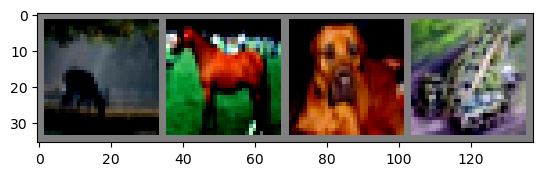

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres legibles para las 10 clases de CIFAR-10, en el orden de sus índices (0-9).
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Función auxiliar para mostrar un tensor de imagen en matplotlib.
def imshow(img):
    # Revierte parcialmente la normalización usada en el dataset para visualizar mejor.
    img = img / 2 + 0.5
    # Convierte el tensor a numpy para poder dibujarlo con matplotlib.
    npimg = img.numpy()
    # Cambia de formato CHW (canal, alto, ancho) a HWC (alto, ancho, canal).
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Crea un iterador sobre el DataLoader "trainloader" para obtener un mini-batch.
dataiter = iter(trainloader)

# Extrae un batch de muestra para pintalo: images contiene las imágenes y labels sus clases numéricas. 
# "next"es una función python que obtiene el siguiente elemento del iterador, en este caso un batch de datos.
images, labels = next(dataiter)

# Verifica que 'images' es un tensor de PyTorch.
print(f"Tipo de la variable images: {type(images)}, tipo de la variable labels: {type(labels)}") 

# Debe ser (4, 3, 32, 32): 4 imágenes, 3 canales, 32x32 píxeles cada una.
print(f"Shape de la variable images: {images.shape}")  

# Muestra en una sola cuadrícula las imágenes del batch.
imshow(torchvision.utils.make_grid(images))
# Imprime las etiquetas en texto para las 4 imágenes del batch.
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

Running the above cell should show you a strip of four images, and the
correct label for each.

Training Your PyTorch Model
===========================

Follow along with the video beginning at
[17:10](https://www.youtube.com/watch?v=IC0_FRiX-sw&t=1030s).

Let's put all the pieces together, and train a model:


In [14]:
#%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

First, we'll need training and test datasets. If you haven't already,
run the cell below to make sure the dataset is downloaded. (It may take
a minute.)


In [15]:
# Pipeline de transformaciones aplicado a cada imagen de CIFAR-10.
transform = transforms.Compose(
    [transforms.ToTensor(),  # Convierte imagen (PIL/ndarray) a tensor con forma CxHxW y valores en [0, 1].
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])  # Normaliza cada canal RGB alrededor de 0.

# Dataset de entrenamiento: 50k imágenes.
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
# DataLoader de entrenamiento: entrega mini-batches de 4 imágenes en orden aleatorio.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

# Dataset de prueba: 10k imágenes.
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
# DataLoader de prueba: no mezcla el orden para evaluación reproducible.
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

# Nombres legibles de las clases de CIFAR-10 (índice 0 a 9).
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

We'll run our check on the output from `DataLoader`:


plane   car   car  frog


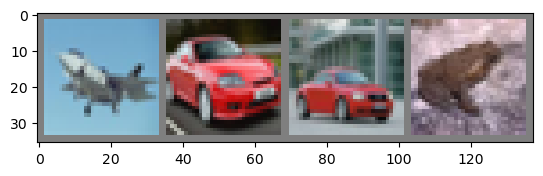

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images, concretamente un batch de 4 imágenes, para visualizarlas.
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

This is the model we'll train. If it looks familiar, that's because it's
a variant of LeNet - discussed earlier in this video - adapted for
3-color images.


In [ ]:
class Net(nn.Module):
    def __init__(self):
        # Inicializa la clase base nn.Module (necesario para que PyTorch registre las capas).
        super(Net, self).__init__()
        # Primera convolución: 3 canales de entrada (RGB), 6 mapas de características, kernel 5x5.
        self.conv1 = nn.Conv2d(3, 6, 5)
        # Capa de max-pooling 2x2 para reducir resolución espacial.
        self.pool = nn.MaxPool2d(2, 2)
        # Segunda convolución: 6 canales de entrada, 16 canales de salida, kernel 5x5.
        self.conv2 = nn.Conv2d(6, 16, 5)
        # Capa totalmente conectada: aplana 16*5*5 características a 120 neuronas.
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # Segunda capa totalmente conectada: 120 -> 84 neuronas.
        self.fc2 = nn.Linear(120, 84)
        # Capa de salida: 84 -> 10 logits (una salida por clase de CIFAR-10).
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Bloque 1: convolución -> ReLU -> max-pooling.
        x = self.pool(F.relu(self.conv1(x)))
        # Bloque 2: convolución -> ReLU -> max-pooling.
        x = self.pool(F.relu(self.conv2(x)))
        # Aplana el tensor para pasarlo a las capas lineales.
        x = x.view(-1, 16 * 5 * 5)
        # Capa densa con activación ReLU.
        x = F.relu(self.fc1(x))
        # Capa densa con activación ReLU.
        x = F.relu(self.fc2(x))
        # Capa final: devuelve logits sin softmax (útil para CrossEntropyLoss).
        x = self.fc3(x)
        return x


net = Net()  # Crea una instancia del modelo para entrenar/evaluar.

""" 
            --- CODIFICACIÓN ALTERNATIVA ---
            
class Net(nn.Module):
    def __init__(self):
        # Inicializa la clase base nn.Module 
        super(Net, self).__init__()

        # Primera convolución: 3 canales de entrada (RGB), 6 mapas de características, kernel 5x5.
        self.conv1 = nn.Conv2d(3, 6, 5)
        # Capa de max-pooling 2x2 para reducir resolución espacial.
        self.pool = nn.MaxPool2d(2, 2)
        # Segunda convolución: 6 canales de entrada, 16 canales de salida, kernel 5x5.
        self.conv2 = nn.Conv2d(6, 16, 5)

        # ReLU reutilizable
        self.relu = nn.ReLU()

        # Capas totalmente conectadas
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        # Capa de salida: 84 -> 10 logits (una salida por clase de CIFAR-10).
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Bloque 1: convolución -> ReLU -> max-pooling.
        x = self.pool(self.relu(self.conv1(x)))
        # Bloque 2: convolución -> ReLU -> max-pooling.
        x = self.pool(self.relu(self.conv2(x)))

        # Aplana el tensor para pasarlo a las capas lineales.
        x = x.view(-1, 16 * 5 * 5)

        # Capas densas con ReLU
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))

        # Capa final: devuelve logits sin softmax (útil para CrossEntropyLoss).
        x = self.fc3(x)
        return x         
"""

The last ingredients we need are a loss function and an optimizer:


In [18]:
# Función de pérdida para clasificación multiclase; compara logits del modelo con las etiquetas reales.
loss_function = nn.CrossEntropyLoss()  

# Optimizador SGD que actualiza los pesos usando gradiente, tasa de aprendizaje y momentum.
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)  

The loss function, as discussed earlier in this video, is a measure of
how far from our ideal output the model's prediction was. Cross-entropy
loss is a typical loss function for classification models like ours.

The **optimizer** is what drives the learning. Here we have created an
optimizer that implements *stochastic gradient descent,* one of the more
straightforward optimization algorithms. Besides parameters of the
algorithm, like the learning rate (`lr`) and momentum, we also pass in
`net.parameters()`, which is a collection of all the learning weights in
the model - which is what the optimizer adjusts.

Finally, all of this is assembled into the training loop. Go ahead and
run this cell, as it will likely take a few minutes to execute:


In [ ]:
# Recorre el dataset 2 veces completas (2 épocas de entrenamiento).
for epoch in range(2):  
    # Acumula la pérdida para reportar estadísticas periódicas.
    running_loss = 0.0  
    # Itera mini-batches del DataLoader con índice i. Ya no cogemos solo una muestra de un batch, sino que recorremos todo el DataLoader, que nos va a ir dando batches de 4 imágenes cada vez.
    for i, data in enumerate(trainloader, 0):  
        # Separa el batch en imágenes de entrada y etiquetas reales.
        # "inputs" y "labels" son tensores de Pytorch (torch.Tensor).
        # "labels" es un tensor de enteros, indicando el número de clase, no son etiquetas
        inputs, labels = data

        # Reinicia gradientes acumulados de la iteración anterior.
        optimizer.zero_grad()  

        #                   ---forward + backward + optimize ---
        # Forward: el modelo calcula logits para este batch.
        # "output_logits" es un tensor de flotantes de Pytorch (torch.Tensor) con scores por clase.
        outputs_logits = net(inputs)  
        
        #  ¡¡¡¡IMPORTANTE - SOFTMAX IMPLICITO!!!!
        # Calcula la pérdida comparando predicción vs etiqueta.
        """
        nn.CrossEntropyLoss() compara así:
            Para cada muestra toma el vector de logits (10 valores en el caso de CIFAR10).
            Convierte logits a probabilidades implícitamente con Softmax.
            Usa el entero de labels como clase correcta (por ejemplo 3 = “cat”), y
            penaliza si el logit de la clase correcta no es el más alto.
            
        """
        loss = loss_function(outputs_logits, labels)
        
        # Backward: calcula gradientes de la pérdida respecto a los parámetros.
        loss.backward()  
        
        # Actualiza los pesos del modelo usando SGD.
        optimizer.step()  

        # print statistics
        running_loss += loss.item()  # Suma la pérdida escalar del batch al acumulado.
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))  # Muestra la pérdida media de los últimos 2000 batches.
            running_loss = 0.0  # Reinicia el acumulador para la siguiente ventana de reporte.

print('Finished Training')  # Indica que el entrenamiento ha finalizado.

[1,  2000] loss: 1.037
[1,  4000] loss: 1.068
[1,  6000] loss: 1.049
[1,  8000] loss: 1.034
[1, 10000] loss: 1.046
[1, 12000] loss: 1.043
[2,  2000] loss: 0.943
[2,  4000] loss: 0.976
[2,  6000] loss: 1.007
[2,  8000] loss: 1.021
[2, 10000] loss: 1.013
[2, 12000] loss: 1.001
Finished Training


Here, we are doing only **2 training epochs** (line 1) - that is, two
passes over the training dataset. Each pass has an inner loop that
**iterates over the training data** (line 4), serving batches of
transformed input images and their correct labels.

**Zeroing the gradients** (line 9) is an important step. Gradients are
accumulated over a batch; if we do not reset them for every batch, they
will keep accumulating, which will provide incorrect gradient values,
making learning impossible.

In line 12, we **ask the model for its predictions** on this batch. In
the following line (13), we compute the loss - the difference between
`outputs` (the model prediction) and `labels` (the correct output).

In line 14, we do the `backward()` pass, and calculate the gradients
that will direct the learning.

In line 15, the optimizer performs one learning step - it uses the
gradients from the `backward()` call to nudge the learning weights in
the direction it thinks will reduce the loss.

The remainder of the loop does some light reporting on the epoch number,
how many training instances have been completed, and what the collected
loss is over the training loop.

**When you run the cell above,** you should see something like this:

``` {.sh}
[1,  2000] loss: 2.235
[1,  4000] loss: 1.940
[1,  6000] loss: 1.713
[1,  8000] loss: 1.573
[1, 10000] loss: 1.507
[1, 12000] loss: 1.442
[2,  2000] loss: 1.378
[2,  4000] loss: 1.364
[2,  6000] loss: 1.349
[2,  8000] loss: 1.319
[2, 10000] loss: 1.284
[2, 12000] loss: 1.267
Finished Training
```

Note that the loss is monotonically descending, indicating that our
model is continuing to improve its performance on the training dataset.

As a final step, we should check that the model is actually doing
*general* learning, and not simply "memorizing" the dataset. This is
called **overfitting,** and usually indicates that the dataset is too
small (not enough examples for general learning), or that the model has
more learning parameters than it needs to correctly model the dataset.

This is the reason datasets are split into training and test subsets -to
test the generality of the model, we ask it to make predictions on data
it hasn't trained on:


In [22]:
correct = 0  # Contador de predicciones correctas acumuladas.
total = 0  # Contador total de ejemplos evaluados.

#   --- IMPORTANTE DESACTIVAR EL CÁLCULO DE LOS GRADIENTES EN TEST, YA ESTÁ ENTRENADO EL MDODELO ---
with torch.no_grad():          # Desactiva el cálculo de gradientes para evaluar más rápido y ahorrar memoria.
    for data in testloader:    # Recorre todos los mini-batches del conjunto de prueba.
        images, labels = data  # Separa cada batch en imágenes y etiquetas reales.
        outputs_logits = net(images)  # Forward: obtiene logits/puntuaciones del modelo para cada clase.
        _, predicted_labels = torch.max(outputs_logits.data, 1)      # Toma la clase con mayor puntuación en cada muestra.  _, significa: “ignoro el primer valor que devuelve la función”.
        total += labels.size(0)                               # Suma cuántas muestras hay en este batch.
        correct += (predicted_labels == labels).sum().item()  # Suma cuántas predicciones del batch fueron correctas.
#   --- IMPORTANTE DESACTIVAR EL CÁLCULO DE LOS GRADIENTES EN TEST, YA ESTÁ ENTRENADO EL MDODELO ---



print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))  # Calcula y muestra la precisión total en porcentaje.

Accuracy of the network on the 10000 test images: 60 %


If you followed along, you should see that the model is roughly 50%
accurate at this point. That's not exactly state-of-the-art, but it's
far better than the 10% accuracy we'd expect from a random output. This
demonstrates that some general learning did happen in the model.
